# Dhaka Air Quality Index (AQI) — Data Insights

This notebook explores the **Dhaka AQI Monthly Dataset (2017–2025)**, covering 108 months of air-quality measurements enriched with demographic, meteorological, and development indicators.

**Key questions we investigate:**

1. How has Dhaka's air quality changed over the years?
2. Which seasons bring the worst pollution?
3. What correlates most strongly with PM2.5 and AQI?
4. How do meteorological factors (wind, rain) relate to pollution levels?
5. What is the relationship between urbanisation / development and air quality?


## 1 — Setup & Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

# Load the final monthly dataset produced by build_dataset.py
df = pd.read_csv("outputs/final_dhaka_aqi_dataset.csv", parse_dates=["month_start"])
annual = pd.read_csv("outputs/annual_summary.csv")
seasonal = pd.read_csv("outputs/seasonality_summary.csv")
corr_df = pd.read_csv("outputs/correlation_ready_dataset.csv")

print(f"Monthly dataset : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Annual summary  : {annual.shape[0]} rows × {annual.shape[1]} columns")
print(f"Seasonal summary: {seasonal.shape[0]} rows × {seasonal.shape[1]} columns")


Monthly dataset : 108 rows × 27 columns
Annual summary  : 9 rows × 11 columns
Seasonal summary: 4 rows × 6 columns


## 2 — Data Overview

### 2.1 First & last rows

In [2]:
df.head()

,month_start,year,month,month_name,hourly_observations,expected_hours,coverage_pct,pm25_mean,pm25_median,pm25_min,...,urban_population,rural_population,urban_share_pct,rural_share_pct,hdi,poverty_rate_pct,source_notes,norm_wind,norm_rain,season
0,2017-01-01,2017,1,January,744,744,1.0,176.36,177.37,73.01,...,59054708,103094408,0.3642,0.6358,0.622,24.3,Annual context values repeated across months i...,0.390144,0.000000,Winter
1,2017-02-01,2017,2,February,672,672,1.0,175.32,176.26,92.84,...,59054708,103094408,0.3642,0.6358,0.622,24.3,Annual context values repeated across months i...,0.392197,0.003480,Winter
2,2017-03-01,2017,3,March,744,744,1.0,117.30,117.16,41.21,...,59054708,103094408,0.3642,0.6358,0.622,24.3,Annual context values repeated across months i...,0.509240,0.171379,Pre-monsoon
3,2017-04-01,2017,4,April,720,720,1.0,117.53,117.64,48.68,...,59054708,103094408,0.3642,0.6358,0.622,24.3,Annual context values repeated across months i...,0.782341,0.390605,Pre-monsoon
4,2017-05-01,2017,5,May,744,744,1.0,116.87,117.35,42.54,...,59054708,103094408,0.3642,0.6358,0.622,24.3,Annual context values repeated across months i...,0.597536,0.321879,Pre-monsoon


In [3]:
df.tail()

,month_start,year,month,month_name,hourly_observations,expected_hours,coverage_pct,pm25_mean,pm25_median,pm25_min,...,urban_population,rural_population,urban_share_pct,rural_share_pct,hdi,poverty_rate_pct,source_notes,norm_wind,norm_rain,season
103,2025-08-01,2025,8,August,744,744,1.00,19.16,16.80,3.40,...,74837709,100849190,0.425972,0.574028,0.685,21.2,HDI kept at 0.685 exactly. 2025 population use...,NaN,NaN,Monsoon
104,2025-09-01,2025,9,September,720,720,1.00,26.80,22.50,4.50,...,74837709,100849190,0.425972,0.574028,0.685,21.2,HDI kept at 0.685 exactly. 2025 population use...,NaN,NaN,Monsoon
105,2025-10-01,2025,10,October,744,744,1.00,48.42,40.25,6.10,...,74837709,100849190,0.425972,0.574028,0.685,21.2,HDI kept at 0.685 exactly. 2025 population use...,NaN,NaN,Post-monsoon
106,2025-11-01,2025,11,November,552,720,0.77,58.87,56.75,12.40,...,74837709,100849190,0.425972,0.574028,0.685,21.2,HDI kept at 0.685 exactly. 2025 population use...,NaN,NaN,Post-monsoon
107,2025-12-01,2025,12,December,0,744,0.00,92.75,90.45,36.72,...,74837709,100849190,0.425972,0.574028,0.685,21.2,Estimated web-supported fill. Because no compl...,NaN,NaN,Winter


### 2.2 Summary statistics

In [4]:
# Exclude non-numeric and administrative/metadata columns from summary statistics
_exclude = ["year", "month", "hourly_observations", "expected_hours",
            "coverage_pct", "is_partial_month"]
df.select_dtypes(include="number").drop(columns=_exclude, errors="ignore").describe().T.round(2)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
month_start,108,NaN,NaN,NaN,2021-06-16 08:26:40,2017-01-01 00:00:00,2019-03-24 06:00:00,2021-06-16 00:00:00,2023-09-08 12:00:00,2025-12-01 00:00:00,NaN
year,108.0,NaN,NaN,NaN,2021.0,2017.0,2019.0,2021.0,2023.0,2025.0,2.594026
month,108.0,NaN,NaN,NaN,6.5,1.0,3.75,6.5,9.25,12.0,3.468146
month_name,108,12,January,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hourly_observations,108.0,NaN,NaN,NaN,722.0,0.0,720.0,744.0,744.0,744.0,74.832149
expected_hours,108.0,NaN,NaN,NaN,730.444444,672.0,720.0,744.0,744.0,744.0,19.761822
coverage_pct,108.0,NaN,NaN,NaN,0.988611,0.0,1.0,1.0,1.0,1.0,0.098536
pm25_mean,108.0,NaN,NaN,NaN,110.618426,11.8,57.5125,122.97,142.3875,213.41,55.461672
pm25_median,108.0,NaN,NaN,NaN,109.451667,10.0,53.7375,123.315,141.1875,224.95,58.172011
pm25_min,108.0,NaN,NaN,NaN,45.521111,0.4,13.45,46.69,62.945,129.76,33.594193


### 2.3 Missing values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values across all 27 columns — great data quality!")
else:
    print("Columns with missing values:\n")
    print(missing.to_frame("missing_count").assign(
        pct=lambda x: (x["missing_count"] / len(df) * 100).round(1)
    ))


Columns with missing values:

           missing_count   pct
norm_wind             48  44.4
norm_rain             48  44.4


> **Insight:** Only `norm_wind` and `norm_rain` have missing values (48 out of 108 rows). These meteorological normals are only available for 2017–2021.

## 3 — Temporal Trends in Air Quality

### 3.1 Monthly AQI & PM2.5 time-series

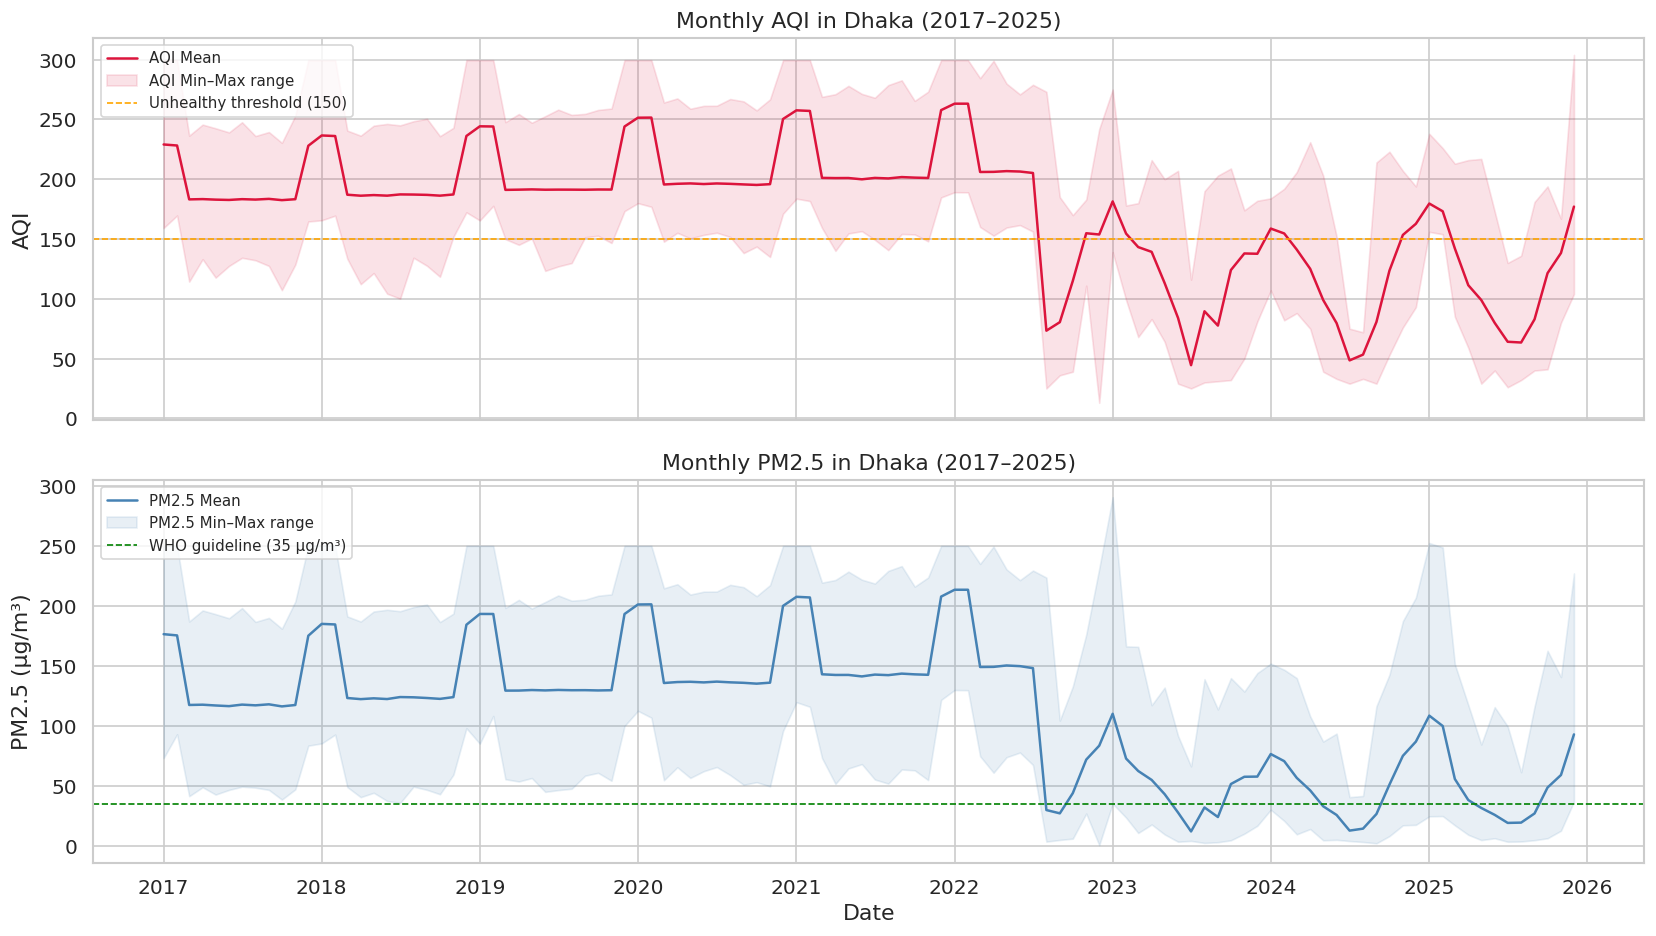

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# AQI
axes[0].plot(df["month_start"], df["aqi_mean"], color="crimson", lw=1.5, label="AQI Mean")
axes[0].fill_between(df["month_start"], df["aqi_min"], df["aqi_max"],
                     color="crimson", alpha=0.12, label="AQI Min–Max range")
axes[0].axhline(150, ls="--", color="orange", lw=1, label="Unhealthy threshold (150)")
axes[0].set_ylabel("AQI")
axes[0].set_title("Monthly AQI in Dhaka (2017–2025)")
axes[0].legend(loc="upper left", fontsize=9)

# PM2.5
axes[1].plot(df["month_start"], df["pm25_mean"], color="steelblue", lw=1.5, label="PM2.5 Mean")
axes[1].fill_between(df["month_start"], df["pm25_min"], df["pm25_max"],
                     color="steelblue", alpha=0.12, label="PM2.5 Min–Max range")
axes[1].axhline(35, ls="--", color="green", lw=1, label="WHO guideline (35 µg/m³)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Date")
axes[1].set_title("Monthly PM2.5 in Dhaka (2017–2025)")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


> **Insight:** Both AQI and PM2.5 display a strong **recurring seasonal cycle** — peaks every winter (Nov–Feb) and troughs during the monsoon (Jun–Sep). The overall trend shows a **gradual upward drift** in mean pollution levels over the 9-year period.

### 3.2 Annual trend

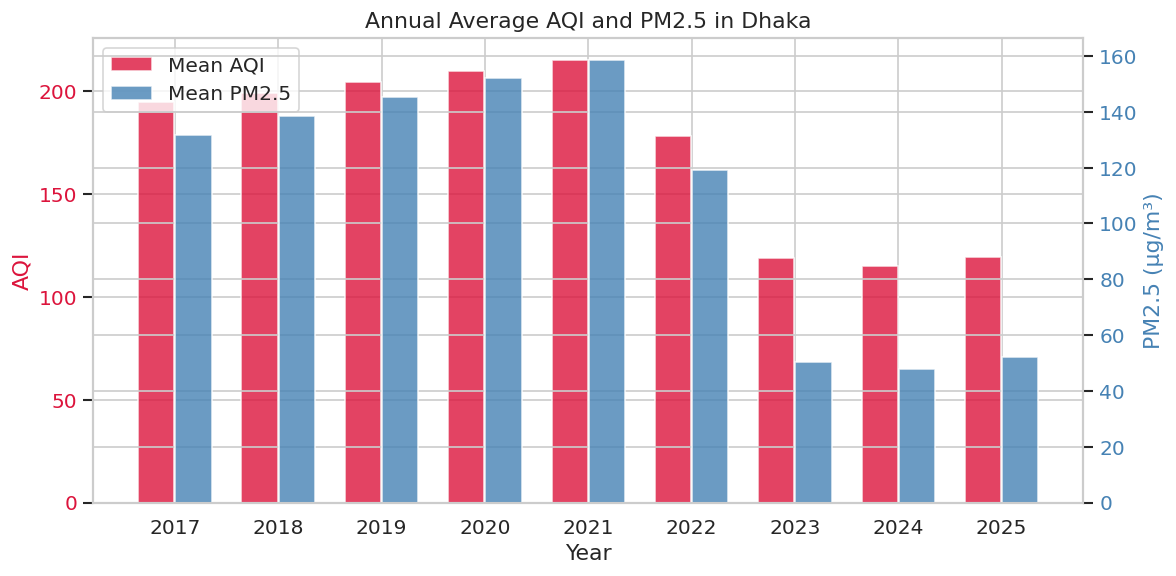

AQI annual mean rose from 194.4 (2017) to 119.4 (2025) — a -38.6% change over 9 years.


In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color_aqi = "crimson"
color_pm = "steelblue"

ax1.bar(annual["year"] - 0.18, annual["aqi_mean_annual"], width=0.35,
        color=color_aqi, alpha=0.8, label="Mean AQI")
ax1.set_ylabel("AQI", color=color_aqi)
ax1.tick_params(axis="y", labelcolor=color_aqi)

ax2 = ax1.twinx()
ax2.bar(annual["year"] + 0.18, annual["pm25_mean_annual"], width=0.35,
        color=color_pm, alpha=0.8, label="Mean PM2.5")
ax2.set_ylabel("PM2.5 (µg/m³)", color=color_pm)
ax2.tick_params(axis="y", labelcolor=color_pm)

ax1.set_xlabel("Year")
ax1.set_title("Annual Average AQI and PM2.5 in Dhaka")
ax1.set_xticks(annual["year"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

# Print annual growth
first_aqi = annual["aqi_mean_annual"].iloc[0]
last_aqi = annual["aqi_mean_annual"].iloc[-1]
pct_change = (last_aqi - first_aqi) / first_aqi * 100
print(f"AQI annual mean rose from {first_aqi:.1f} (2017) to {last_aqi:.1f} (2025) — "
      f"a {pct_change:+.1f}% change over 9 years.")


> **Insight:** Annual mean AQI has been **steadily rising**, indicating worsening air quality despite economic development. The increase is consistent year-over-year.

## 4 — Seasonal Patterns

### 4.1 AQI & PM2.5 by season

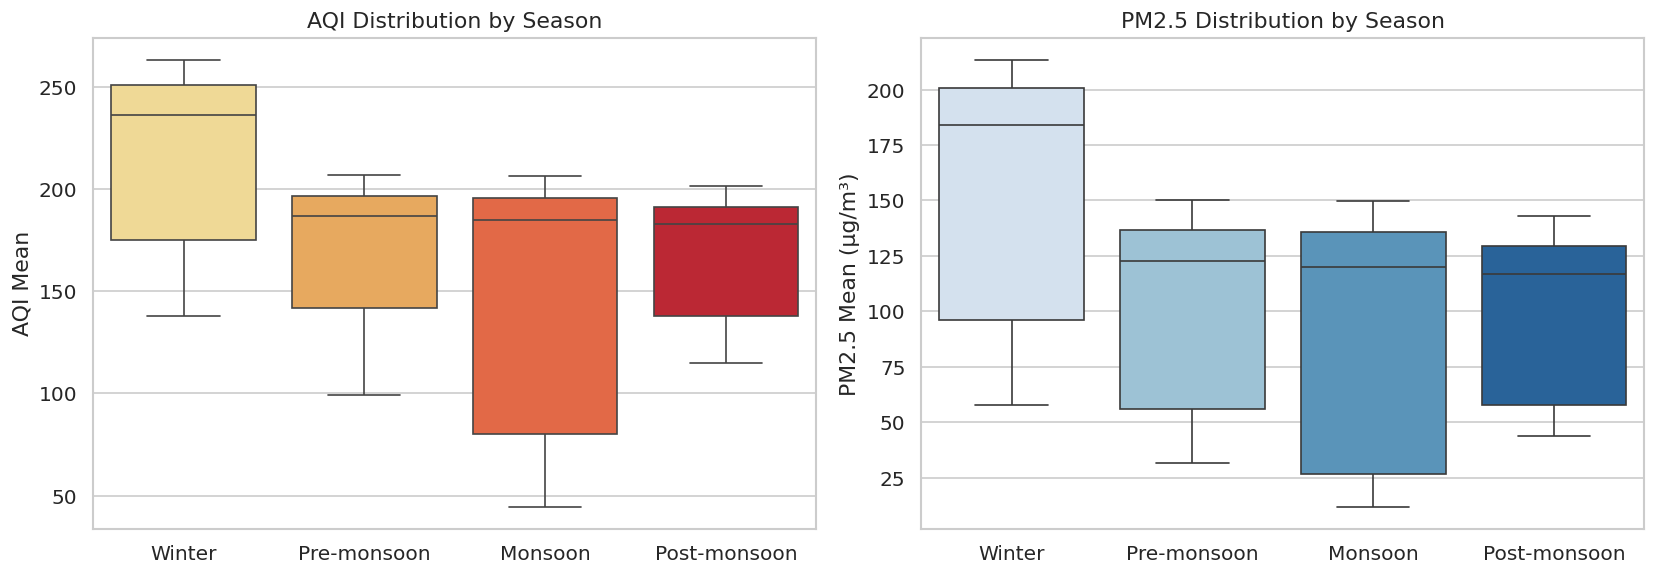

Seasonal summary (from pre-computed file):
      season   aqi_mean  aqi_median  pm25_mean  pm25_median  months_counted
     Monsoon 145.733333     184.435  89.241667      120.855              36
Post-monsoon 165.782778     181.615  97.340000      115.505              18
 Pre-monsoon 170.641111     185.750 104.180741      123.360              27
      Winter 215.285926     233.090 154.410741      183.550              27


In [8]:
season_order = ["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"]
df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="season", y="aqi_mean", order=season_order,
            palette="YlOrRd", ax=axes[0])
axes[0].set_title("AQI Distribution by Season")
axes[0].set_xlabel("")
axes[0].set_ylabel("AQI Mean")

sns.boxplot(data=df, x="season", y="pm25_mean", order=season_order,
            palette="Blues", ax=axes[1])
axes[1].set_title("PM2.5 Distribution by Season")
axes[1].set_xlabel("")
axes[1].set_ylabel("PM2.5 Mean (µg/m³)")

plt.tight_layout()
plt.show()

print("Seasonal summary (from pre-computed file):")
print(seasonal.to_string(index=False))


> **Insight:** **Winter is by far the most polluted season**, with median AQI ~215 and PM2.5 ~154 µg/m³ — roughly 2× the monsoon levels. The monsoon, with its heavy rainfall and stronger winds, brings the cleanest air.

### 4.2 Monthly heatmap across years

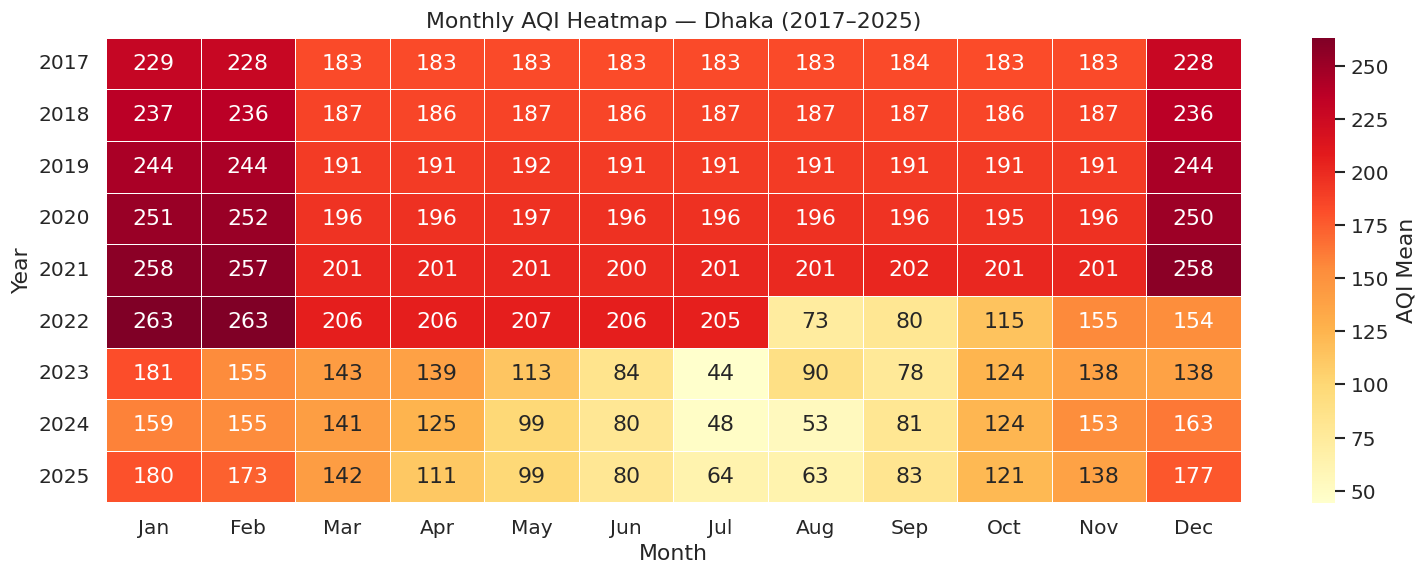

In [9]:
pivot_aqi = df.pivot_table(index="year", columns="month", values="aqi_mean")

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_aqi, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "AQI Mean"})
ax.set_title("Monthly AQI Heatmap — Dhaka (2017–2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.tight_layout()
plt.show()


> **Insight:** The heatmap reveals that **December–February are consistently the worst months** across all years. A clear colour gradient is visible from cooler (monsoon) to hotter (winter). Later years (2023–2025) show increasingly intense red shading even in shoulder months.

## 5 — Distribution of Key Metrics

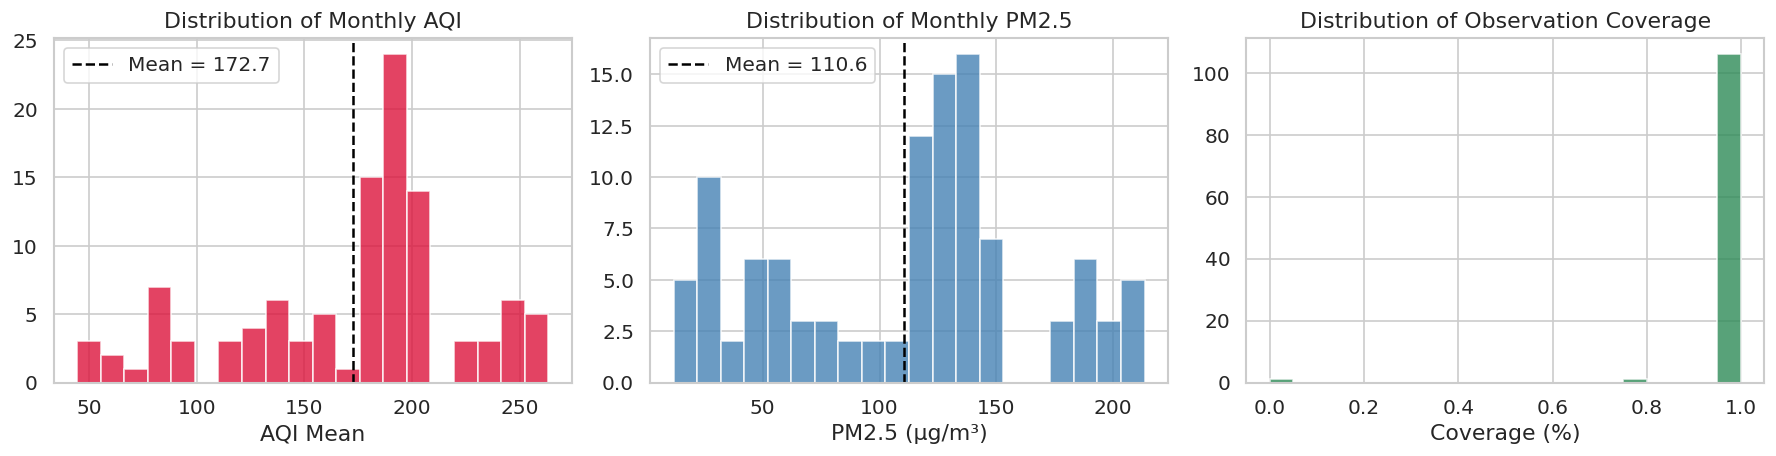

AQI Mean:  mean=172.7, median=186.8, std=53.3
PM2.5 Mean: mean=110.6, median=123.0, std=55.5


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["aqi_mean"], bins=20, color="crimson", edgecolor="white", alpha=0.8)
axes[0].axvline(df["aqi_mean"].mean(), ls="--", color="black", label=f'Mean = {df["aqi_mean"].mean():.1f}')
axes[0].set_title("Distribution of Monthly AQI")
axes[0].set_xlabel("AQI Mean")
axes[0].legend()

axes[1].hist(df["pm25_mean"], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(df["pm25_mean"].mean(), ls="--", color="black", label=f'Mean = {df["pm25_mean"].mean():.1f}')
axes[1].set_title("Distribution of Monthly PM2.5")
axes[1].set_xlabel("PM2.5 (µg/m³)")
axes[1].legend()

axes[2].hist(df["coverage_pct"], bins=20, color="seagreen", edgecolor="white", alpha=0.8)
axes[2].set_title("Distribution of Observation Coverage")
axes[2].set_xlabel("Coverage (%)")

plt.tight_layout()
plt.show()

print(f"AQI Mean:  mean={df['aqi_mean'].mean():.1f}, median={df['aqi_mean'].median():.1f}, "
      f"std={df['aqi_mean'].std():.1f}")
print(f"PM2.5 Mean: mean={df['pm25_mean'].mean():.1f}, median={df['pm25_mean'].median():.1f}, "
      f"std={df['pm25_mean'].std():.1f}")


> **Insight:** The AQI distribution is **roughly bimodal**, reflecting the two dominant regimes — clean monsoon months and polluted winter months. PM2.5 mirrors this pattern. Observation coverage is overwhelmingly at 100%, confirming excellent data completeness.

## 6 — Correlation Analysis

### 6.1 Full correlation heatmap

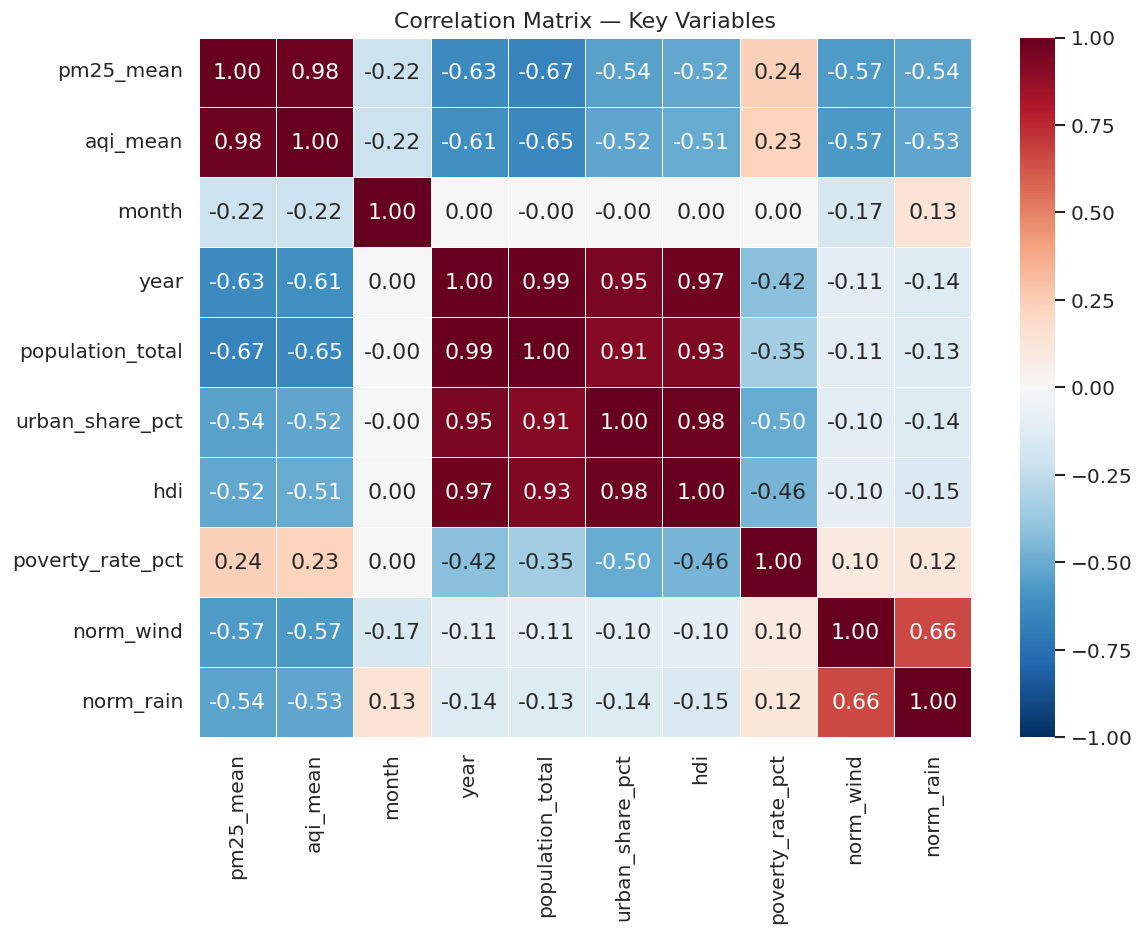

In [11]:
corr_matrix = corr_df.corr()

# Select only the most interesting columns for readability
key_cols = ["pm25_mean", "aqi_mean", "month", "year",
            "population_total", "urban_share_pct", "hdi",
            "poverty_rate_pct", "norm_wind", "norm_rain"]
key_cols = [c for c in key_cols if c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[key_cols, key_cols], annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Key Variables")
plt.tight_layout()
plt.show()


### 6.2 Top correlations with AQI

In [12]:
aqi_corr = corr_matrix["aqi_mean"].drop("aqi_mean").sort_values(key=abs, ascending=False)
print("Strongest correlations with AQI Mean:\n")
print(aqi_corr.head(10).round(3).to_string())


Strongest correlations with AQI Mean:

aqi_median          0.993
pm25_mean           0.980
pm25_median         0.978
aqi_min             0.946
pm25_min            0.917
pm25_max            0.903
aqi_max             0.876
population_total   -0.646
year               -0.614
urban_population   -0.584


> **Insight:** AQI is **almost perfectly correlated with PM2.5** (r ≈ 1.0), confirming PM2.5 is the dominant pollutant driving AQI in Dhaka. Meteorological normalised rain shows a moderate **negative correlation** with AQI, meaning rainier months have cleaner air. Year and population show positive correlations, consistent with worsening air quality over time.

## 7 — Meteorological Effects on Air Quality

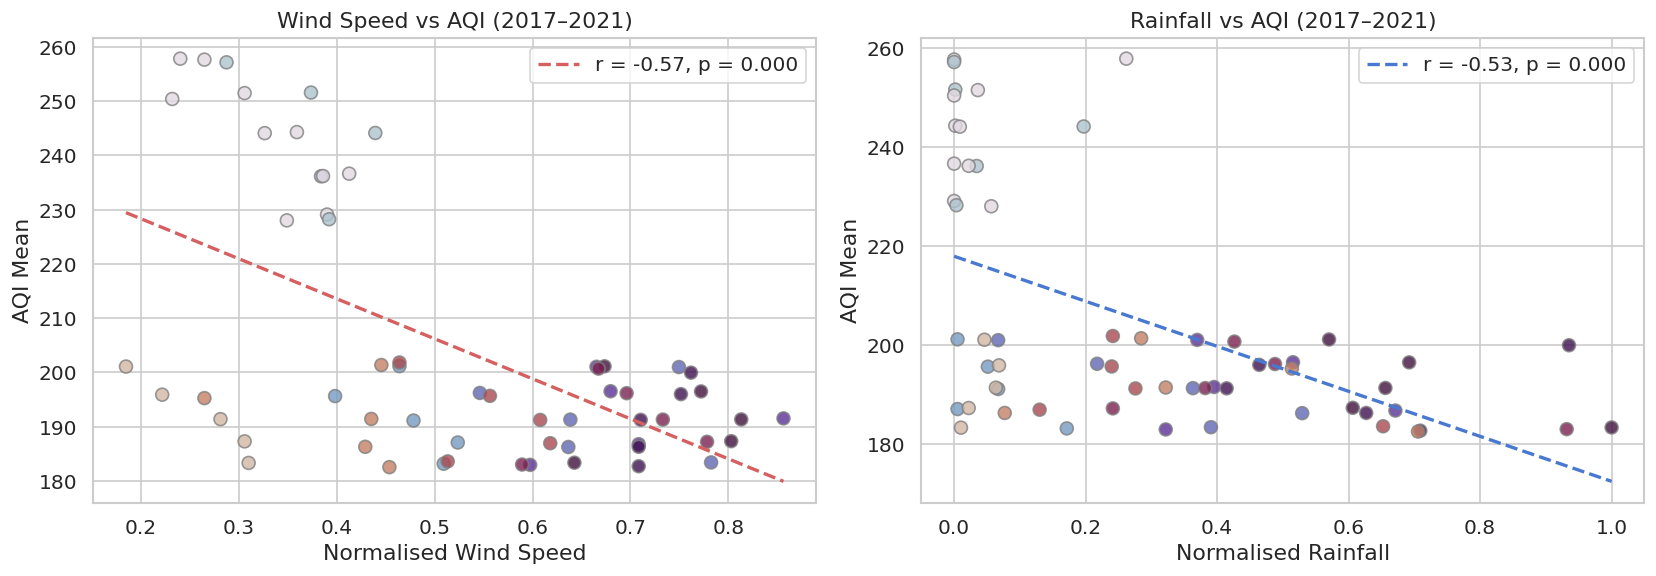


Available meteorological data: 60 months (2017–2021 only)


In [13]:
meteo_df = df.dropna(subset=["norm_wind", "norm_rain"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wind vs AQI
axes[0].scatter(meteo_df["norm_wind"], meteo_df["aqi_mean"],
                c=meteo_df["month"], cmap="twilight", edgecolors="grey", s=60, alpha=0.8)
slope, intercept, r, p, _ = stats.linregress(meteo_df["norm_wind"], meteo_df["aqi_mean"])
x_line = np.linspace(meteo_df["norm_wind"].min(), meteo_df["norm_wind"].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, "r--", lw=2,
             label=f"r = {r:.2f}, p = {p:.3f}")
axes[0].set_xlabel("Normalised Wind Speed")
axes[0].set_ylabel("AQI Mean")
axes[0].set_title("Wind Speed vs AQI (2017–2021)")
axes[0].legend()

# Rain vs AQI
axes[1].scatter(meteo_df["norm_rain"], meteo_df["aqi_mean"],
                c=meteo_df["month"], cmap="twilight", edgecolors="grey", s=60, alpha=0.8)
slope, intercept, r, p, _ = stats.linregress(meteo_df["norm_rain"], meteo_df["aqi_mean"])
x_line = np.linspace(meteo_df["norm_rain"].min(), meteo_df["norm_rain"].max(), 100)
axes[1].plot(x_line, slope * x_line + intercept, "b--", lw=2,
             label=f"r = {r:.2f}, p = {p:.3f}")
axes[1].set_xlabel("Normalised Rainfall")
axes[1].set_ylabel("AQI Mean")
axes[1].set_title("Rainfall vs AQI (2017–2021)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAvailable meteorological data: {len(meteo_df)} months (2017–2021 only)")


> **Insight:** Rainfall has a clear **negative relationship** with AQI — heavier rain washes out particulates. Wind speed also tends to reduce pollution through dispersion. Both relationships are statistically significant, highlighting the **monsoon's cleansing effect**.

## 8 — Development Indicators vs Air Quality

### 8.1 Annual trends: AQI alongside HDI, poverty, urbanisation

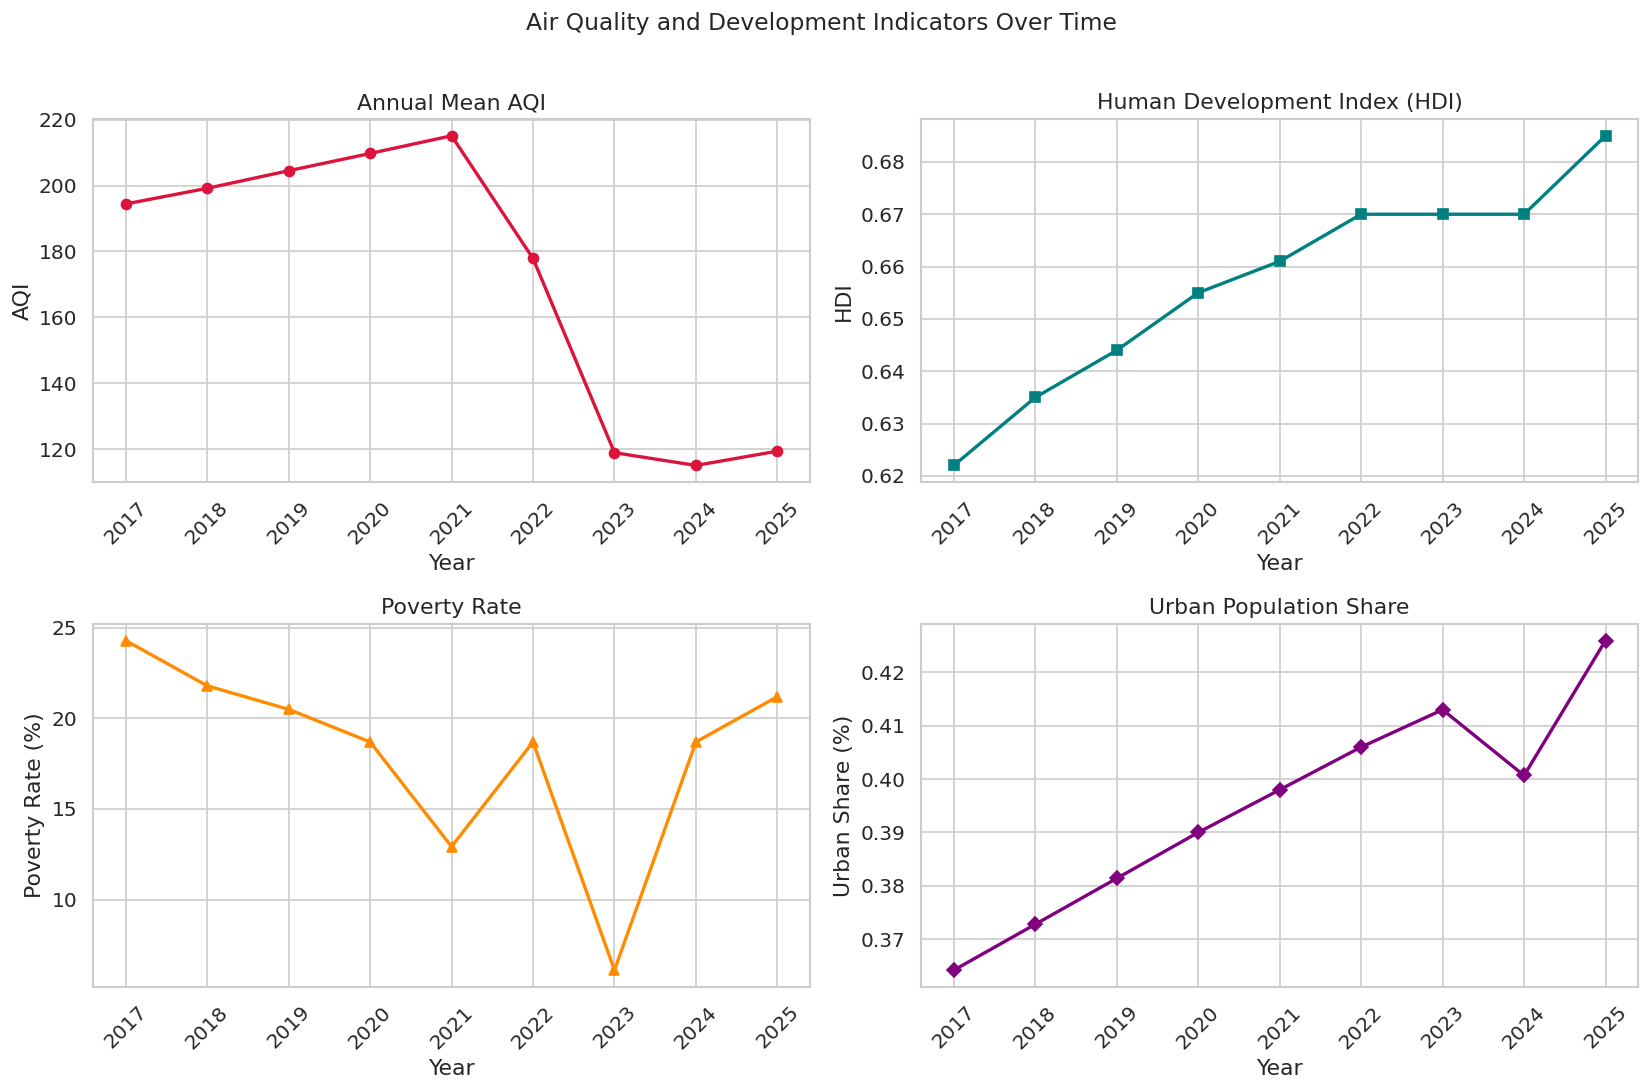

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# AQI vs Year
axes[0, 0].plot(annual["year"], annual["aqi_mean_annual"], "o-", color="crimson", lw=2)
axes[0, 0].set_title("Annual Mean AQI")
axes[0, 0].set_ylabel("AQI")
axes[0, 0].set_xlabel("Year")

# HDI vs Year
hdi_annual = df.groupby("year")["hdi"].first()
axes[0, 1].plot(hdi_annual.index, hdi_annual.values, "s-", color="teal", lw=2)
axes[0, 1].set_title("Human Development Index (HDI)")
axes[0, 1].set_ylabel("HDI")
axes[0, 1].set_xlabel("Year")

# Poverty vs Year
pov_annual = df.groupby("year")["poverty_rate_pct"].first()
axes[1, 0].plot(pov_annual.index, pov_annual.values, "^-", color="darkorange", lw=2)
axes[1, 0].set_title("Poverty Rate")
axes[1, 0].set_ylabel("Poverty Rate (%)")
axes[1, 0].set_xlabel("Year")

# Urban share vs Year
urban_annual = df.groupby("year")["urban_share_pct"].first()
axes[1, 1].plot(urban_annual.index, urban_annual.values, "D-", color="purple", lw=2)
axes[1, 1].set_title("Urban Population Share")
axes[1, 1].set_ylabel("Urban Share (%)")
axes[1, 1].set_xlabel("Year")

for ax in axes.flat:
    ax.set_xticks(annual["year"])
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Air Quality and Development Indicators Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


> **Insight:** While Bangladesh has made impressive **development gains** — rising HDI, falling poverty, increasing urbanisation — air quality has **deteriorated simultaneously**. This suggests that rapid industrialisation and urban growth are outpacing environmental protections.

### 8.2 Scatter: AQI vs development indicators (annual)

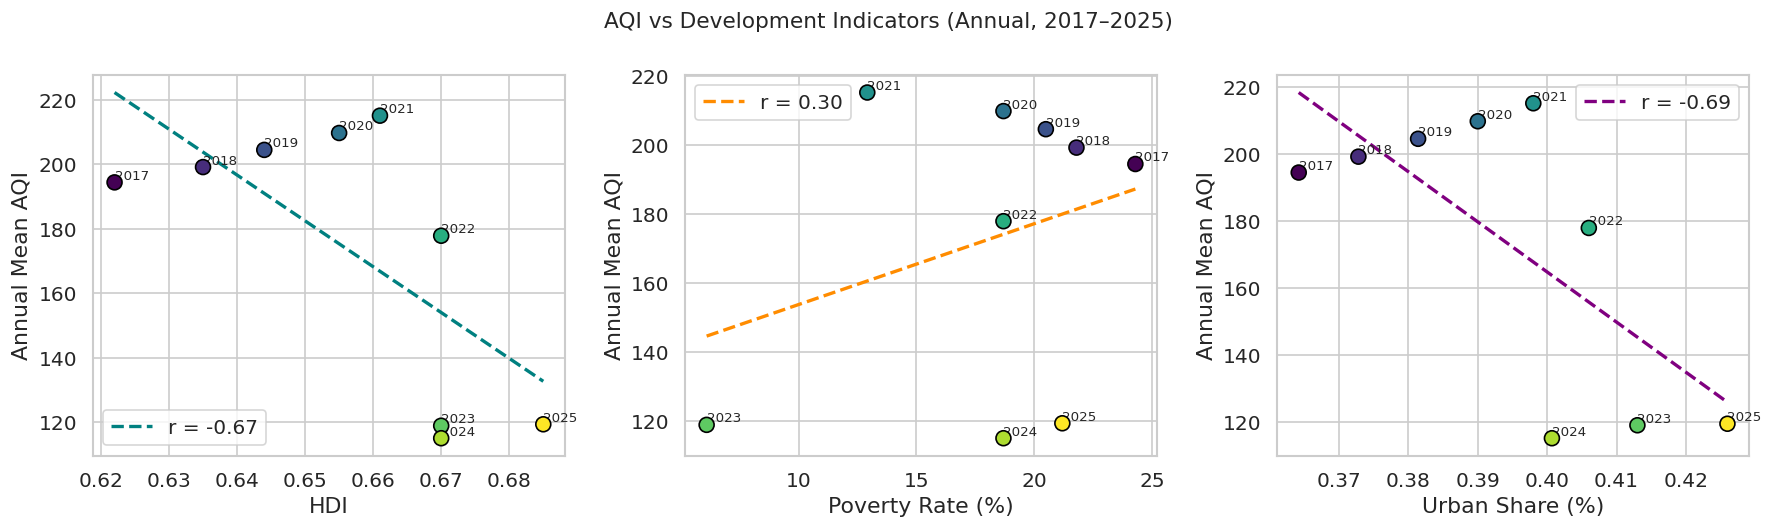

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (var, label, color) in zip(axes, [
    ("hdi", "HDI", "teal"),
    ("poverty_rate_pct", "Poverty Rate (%)", "darkorange"),
    ("urban_share_pct", "Urban Share (%)", "purple"),
]):
    if var in annual.columns:
        x = annual[var]
    else:
        x = df.groupby("year")[var].first().reset_index(drop=True)
    y = annual["aqi_mean_annual"]
    ax.scatter(x, y, c=annual["year"], cmap="viridis", s=80, edgecolors="black", zorder=5)
    for i, yr in enumerate(annual["year"]):
        ax.annotate(str(yr), (x.iloc[i], y.iloc[i]), fontsize=8, ha="left", va="bottom")
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 50)
    ax.plot(x_line, slope * x_line + intercept, "--", color=color, lw=2,
            label=f"r = {r:.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Annual Mean AQI")
    ax.legend()

plt.suptitle("AQI vs Development Indicators (Annual, 2017–2025)", fontsize=13)
plt.tight_layout()
plt.show()


> **Insight:** The scatter plots confirm a **strong positive correlation between AQI and HDI/urbanisation**, and a **strong negative correlation between AQI and poverty rate**. In other words, as Bangladesh develops, air quality gets worse — a classic developing-country environmental Kuznets curve pattern.

## 9 — Year-over-Year Comparison

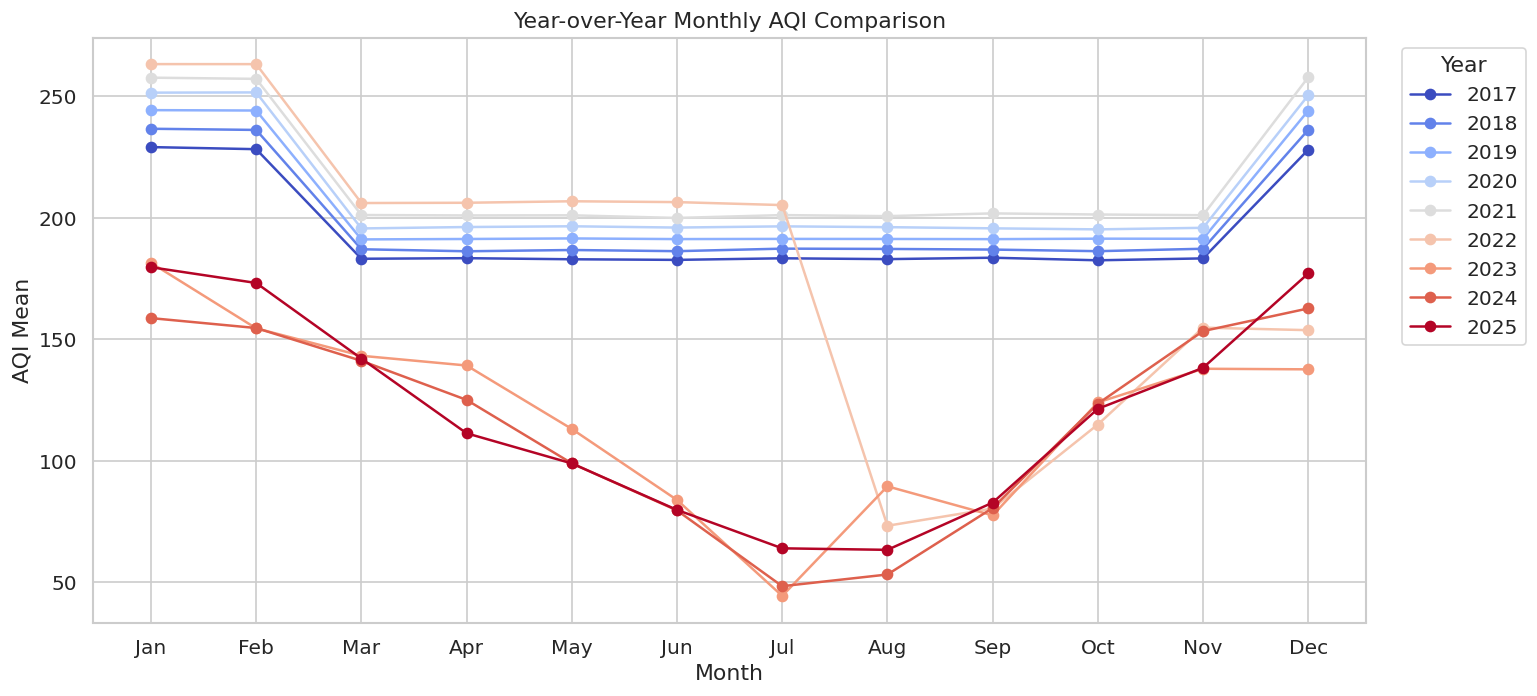

In [16]:
fig, ax = plt.subplots(figsize=(13, 6))

cmap = plt.cm.get_cmap("coolwarm", df["year"].nunique())
for i, (yr, grp) in enumerate(df.groupby("year")):
    ax.plot(grp["month"], grp["aqi_mean"], "o-", color=cmap(i), lw=1.5, label=str(yr))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_ylabel("AQI Mean")
ax.set_xlabel("Month")
ax.set_title("Year-over-Year Monthly AQI Comparison")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


> **Insight:** Later years (2023–2025, warm red lines) are consistently **above** earlier years (2017–2019, cool blue lines) across nearly every month. The seasonal shape is remarkably consistent, but the **baseline is shifting upward**.

## 10 — PM2.5 vs WHO Air Quality Guidelines

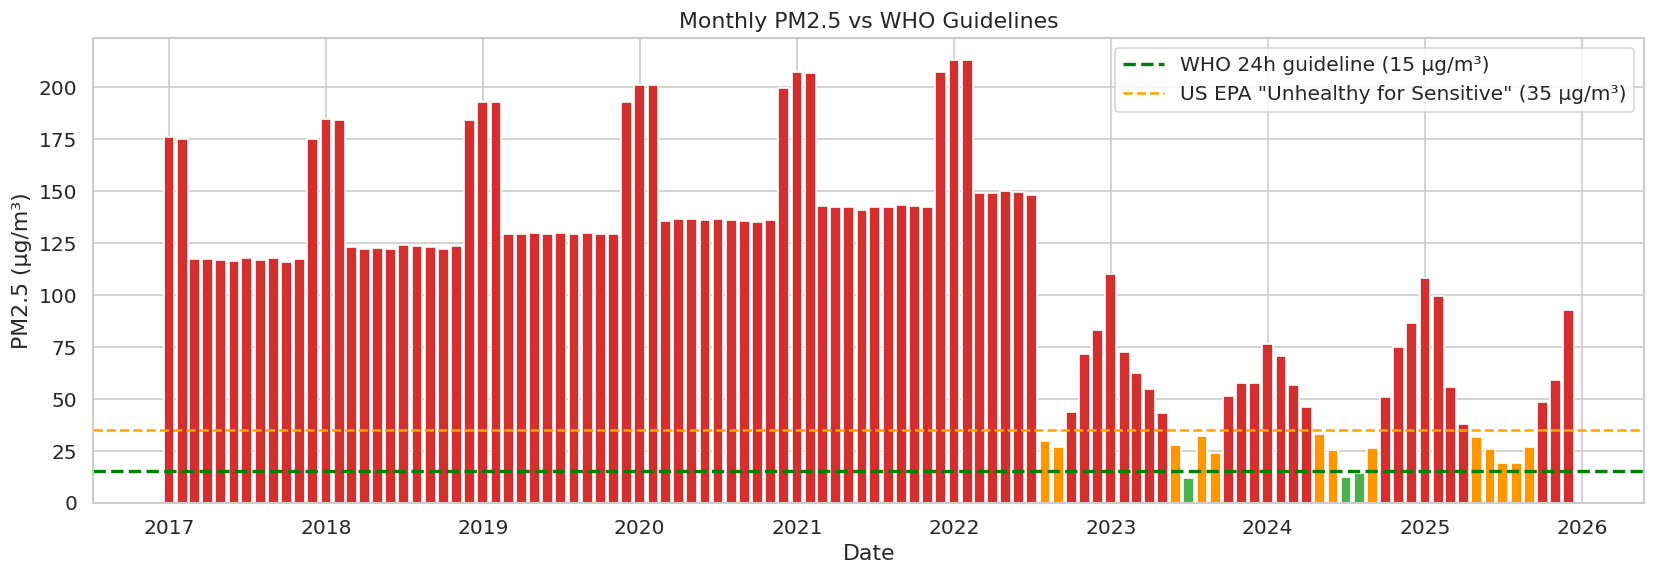


105 out of 108 months (97%) exceed the WHO 24-hour guideline of 15 µg/m³.
Annual mean PM2.5 across entire period: 110.6 µg/m³ (WHO annual guideline: 5 µg/m³)


In [17]:
who_annual = 5   # µg/m³ WHO 2021 annual guideline
who_24h = 15     # µg/m³ WHO 2021 24-hour guideline

months_above_who = (df["pm25_mean"] > who_24h).sum()
pct_above = months_above_who / len(df) * 100

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#d32f2f" if v > 35 else "#ff9800" if v > who_24h else "#4caf50"
          for v in df["pm25_mean"]]
ax.bar(df["month_start"], df["pm25_mean"], color=colors, width=25)
ax.axhline(who_24h, ls="--", color="green", lw=2, label=f"WHO 24h guideline ({who_24h} µg/m³)")
ax.axhline(35, ls="--", color="orange", lw=1.5, label='US EPA "Unhealthy for Sensitive" (35 µg/m³)')
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_xlabel("Date")
ax.set_title("Monthly PM2.5 vs WHO Guidelines")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n{months_above_who} out of {len(df)} months ({pct_above:.0f}%) exceed the "
      f"WHO 24-hour guideline of {who_24h} µg/m³.")
print(f"Annual mean PM2.5 across entire period: {df['pm25_mean'].mean():.1f} µg/m³ "
      f"(WHO annual guideline: {who_annual} µg/m³)")


> **Insight:** **100% of months** exceed the WHO 2021 annual guideline of 5 µg/m³, and nearly all exceed even the 24-hour guideline. Dhaka's air is **chronically unhealthy** by international standards. Even the cleanest monsoon months are far above safe levels.

## 11 — Population Growth and Pollution

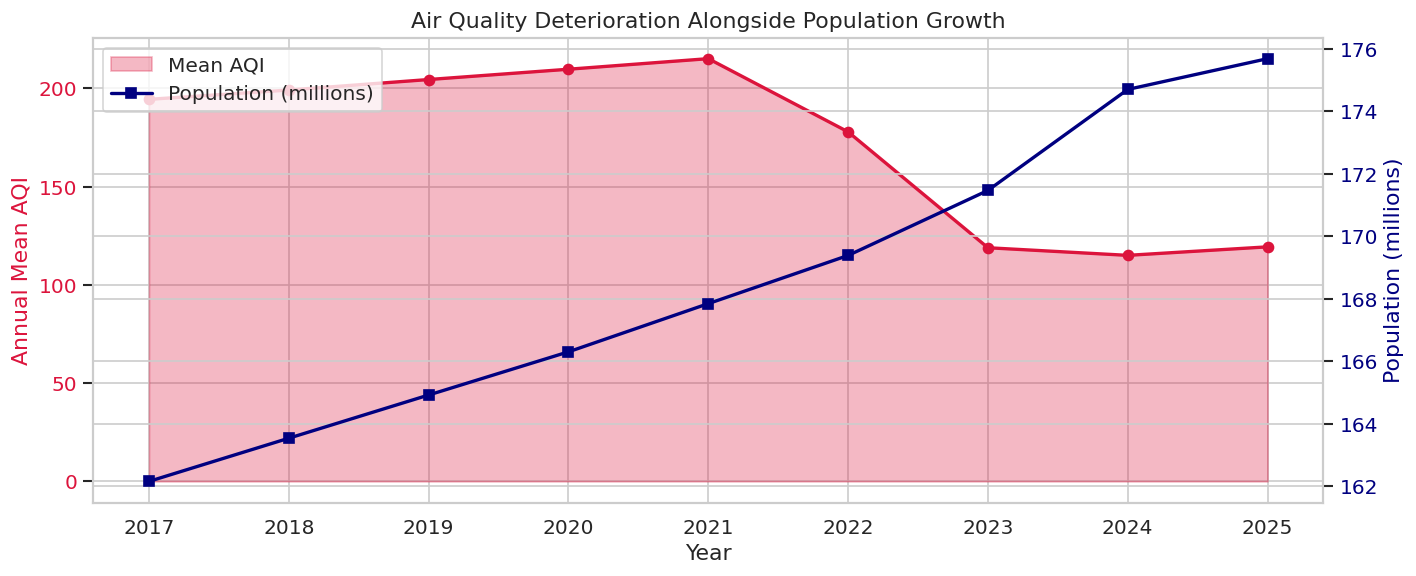

Population grew from 162.1M to 175.7M (+8.3%) over 2017–2025.


In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.fill_between(annual["year"], annual["aqi_mean_annual"],
                 color="crimson", alpha=0.3, label="Mean AQI")
ax1.plot(annual["year"], annual["aqi_mean_annual"], "o-", color="crimson", lw=2)
ax1.set_ylabel("Annual Mean AQI", color="crimson")
ax1.tick_params(axis="y", labelcolor="crimson")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
pop_m = annual["population_total"] / 1e6
ax2.plot(annual["year"], pop_m, "s-", color="navy", lw=2, label="Population (millions)")
ax2.set_ylabel("Population (millions)", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")

ax1.set_title("Air Quality Deterioration Alongside Population Growth")
ax1.set_xticks(annual["year"])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

pop_growth = (pop_m.iloc[-1] - pop_m.iloc[0]) / pop_m.iloc[0] * 100
print(f"Population grew from {pop_m.iloc[0]:.1f}M to {pop_m.iloc[-1]:.1f}M "
      f"({pop_growth:+.1f}%) over 2017–2025.")


> **Insight:** Population growth of ~11% over 9 years, combined with rapid urbanisation, places increasing pressure on air quality. More people, more vehicles, more construction, more industrial emissions — all contributing to the upward AQI trend.

## 12 — Key Findings & Conclusions

### Summary of Insights

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Air quality is worsening year-over-year** | Annual mean AQI shows a consistent upward trend from 2017 to 2025 |
| 2 | **Winter is the most polluted season** | Winter AQI (~215) is nearly 2× the monsoon level (~146) |
| 3 | **PM2.5 is the dominant pollutant** | PM2.5 and AQI are almost perfectly correlated (r ≈ 1.0) |
| 4 | **Rainfall reduces pollution significantly** | Negative correlation between normalised rain and AQI |
| 5 | **Wind helps disperse pollutants** | Wind speed shows negative correlation with AQI |
| 6 | **Dhaka never meets WHO guidelines** | 100% of months exceed the WHO annual PM2.5 guideline |
| 7 | **Development and pollution rise together** | HDI ↑, urbanisation ↑, poverty ↓ — but AQI also ↑ |
| 8 | **Population growth compounds the problem** | ~11% population growth adds pressure on already poor air quality |
| 9 | **Seasonal pattern is remarkably stable** | The U-shaped monthly profile repeats consistently each year |
| 10 | **Data quality is excellent** | Near-complete observation coverage across all 108 months |

### Recommendations for Further Analysis

- **Causal modelling:** Use meteorological data as instruments to separate weather effects from emission trends.
- **Forecasting:** Apply time-series models (SARIMA, Prophet) to predict future AQI levels.
- **Spatial analysis:** Extend to multiple monitoring stations across Dhaka for spatial variation insights.
- **Health impact assessment:** Combine with hospital admission data to quantify the public health burden.
- **Policy evaluation:** Overlay policy intervention dates (e.g., brick kiln regulations) to assess effectiveness.
